In [1]:
# Cell 1 — Environment Setup and Imports


from pathlib import Path
import sys


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt


import torch
import torch.nn as nn


from torchvision import (
    datasets,
    transforms,
    models
)


from torch.utils.data import DataLoader


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


print("Environment initialized")


print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print(f"Device      : {device}")


if torch.cuda.is_available():

    print(
        f"GPU         : {torch.cuda.get_device_name(0)}"
    )

Environment initialized
Python      : 3.12.3
PyTorch     : 2.14.0.dev20260621+cu130
Device      : cuda
GPU         : NVIDIA GeForce RTX 5070 Ti


In [2]:
# Cell 2 — Paths


datasetPath = Path("../dataset")


testPath = datasetPath / "test"


modelPath = Path(
   "../models/bestVGG19.pth"
)


resultsPath = Path("../results")


resultsPath.mkdir(
    exist_ok=True
)


print("Dataset:", testPath.exists())


print("Model:", modelPath.exists())

Dataset: True
Model: True


In [3]:
# Cell 3 — Test Dataset


testTransform = transforms.Compose(
    [

        transforms.Resize((224,224)),

        transforms.ToTensor(),

        transforms.Normalize(

            mean=[
                0.485,
                0.456,
                0.406
            ],

            std=[
                0.229,
                0.224,
                0.225
            ]

        )

    ]
)



testDataset = datasets.ImageFolder(

    testPath,

    transform=testTransform

)



testLoader = DataLoader(

    testDataset,

    batch_size=64,

    shuffle=False

)



classNames = testDataset.classes


numClasses = len(classNames)



print("Classes:")

print(classNames)



print(
    "Test images:",
    len(testDataset)
)

Classes:
['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']
Test images: 2800


In [4]:
# Load VGG19


model = models.vgg19(

    weights=None

)


inputFeatures = model.classifier[6].in_features


model.classifier[6] = nn.Linear(

    inputFeatures,

    numClasses

)


checkpoint = torch.load(

    modelPath,

    map_location="cpu"

)


model.load_state_dict(checkpoint)


model = model.to(device)


model.eval()


print("VGG19 model loaded")

VGG19 model loaded


In [5]:
# Cell 5 — Predictions


trueLabels = []


predictedLabels = []



with torch.no_grad():


    for images, labels in testLoader:


        images = images.to(device)


        outputs = model(images)



        _, predictions = torch.max(

            outputs,

            1

        )



        trueLabels.extend(

            labels.numpy()

        )



        predictedLabels.extend(

            predictions.cpu().numpy()

        )



print(
    "Prediction complete"
)

Prediction complete


In [6]:
# Cell 6 — Metrics


testAccuracy = accuracy_score(
    trueLabels,
    predictedLabels
)


testPrecision = precision_score(

    trueLabels,
    predictedLabels,
    average="weighted"

)


testRecall = recall_score(

    trueLabels,
    predictedLabels,
    average="weighted"

)


testF1 = f1_score(

    trueLabels,
    predictedLabels,
    average="weighted"

)



print(f"Accuracy  : {testAccuracy:.4f}")

print(f"Precision : {testPrecision:.4f}")

print(f"Recall    : {testRecall:.4f}")

print(f"F1 Score  : {testF1:.4f}")

Accuracy  : 0.2043
Precision : 0.1260
Recall    : 0.2043
F1 Score  : 0.1230


In [8]:
# Cell 7 — Classification Report


report = classification_report(

    trueLabels,

    predictedLabels,

    target_names=classNames

)



print(report)



with open(

     "../results/vgg19_classification_report.txt",

    "w"

) as file:


    file.write(report)

              precision    recall  f1-score   support

         AMD       0.26      0.40      0.31       350
         CNV       0.00      0.00      0.00       350
         CSR       0.16      0.02      0.04       350
         DME       0.10      0.02      0.03       350
          DR       0.05      0.01      0.02       350
      DRUSEN       0.00      0.00      0.00       350
          MH       0.19      0.89      0.31       350
      NORMAL       0.26      0.30      0.28       350

    accuracy                           0.20      2800
   macro avg       0.13      0.20      0.12      2800
weighted avg       0.13      0.20      0.12      2800



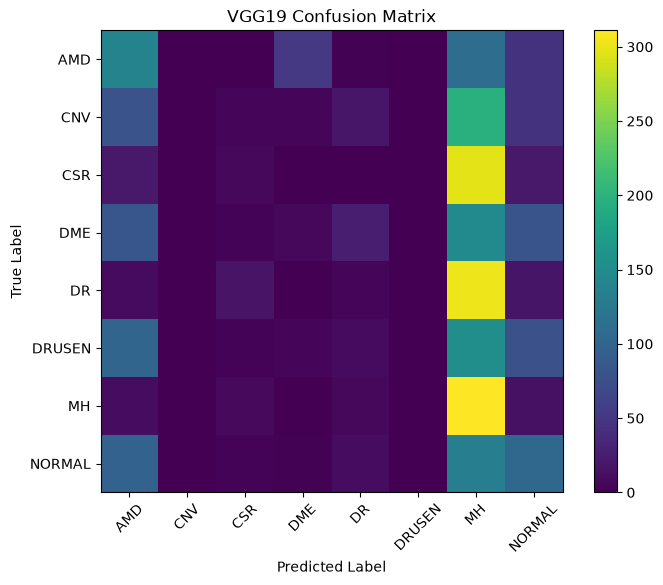

In [9]:
# Cell 8 — Confusion Matrix


cm = confusion_matrix(

    trueLabels,

    predictedLabels

)



plt.figure(
    figsize=(8,6)
)



plt.imshow(
    cm
)



plt.colorbar()



plt.xticks(

    range(len(classNames)),

    classNames,

    rotation=45

)



plt.yticks(

    range(len(classNames)),

    classNames

)



plt.xlabel(
    "Predicted Label"
)



plt.ylabel(
    "True Label"
)



plt.title(
    "VGG19 Confusion Matrix"
)



plt.savefig(

    "../results/vgg19_confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)



plt.show()

In [ ]:
# Cell 9 — Experiment Summary


summary = f"""

Model: VGG19

Dataset: Retinal OCT Dataset


Classes:
{classNames}


Test Accuracy : {testAccuracy:.4f}

Precision     : {testPrecision:.4f}

Recall        : {testRecall:.4f}

F1 Score      : {testF1:.4f}

"""


print(summary)



with open(

"../results/vgg19_summary.txt",
    "w"

) as file:


    file.write(summary)



Model: VGG19

Dataset: Retinal OCT Dataset


Classes:
['AMD', 'CNV', 'CSR', 'DME', 'DR', 'DRUSEN', 'MH', 'NORMAL']


Test Accuracy : 0.2043

Precision     : 0.1260

Recall        : 0.2043

F1 Score      : 0.1230




: 